# Laboratorium 5 — Regresja: porównanie modeli (R)

**Dataset:** `mtcars` (wbudowany w R) — 32 obserwacje, 11 zmiennych, target: `mpg` (mile na galon).

**Plan zadania:**
1. Porównanie modeli: regresja liniowa (`lm`), Ridge (`MASS::lm.ridge`), sieć neuronowa (`nnet`).
2. Analiza ważności cech w modelu Ridge.
3. Analiza reszt — normalność (Shapiro-Wilk) i autokorelacja (Durbin-Watson — ręcznie, bez `lmtest`).
4. Porównanie jakości modeli na danych oryginalnych vs znormalizowanych.

**Pakiety:** `MASS` + `nnet` — oba w bazowym R, **nie wymagają `install.packages()`**.

> Notatnik wymaga **R kernel (IRkernel)** w Jupyterze. Jeśli wolisz uruchomić jako zwykły skrypt: jest też wersja `zad_5_R.R` (uruchom `Rscript zad_5_R.R`).

## 0. Załadowanie bibliotek

In [1]:
library(MASS)
library(nnet)
set.seed(42)

options(jupyter.plot_mimetypes = "image/png")
windowsFonts(Arial = windowsFont("Arial"))
par(family = "Arial")


## 1. Dane — `mtcars`

In [2]:
data(mtcars)
cat("Wymiary mtcars:", dim(mtcars), "\n")
cat("Kolumny:", colnames(mtcars), "\n")
head(mtcars)


Wymiary mtcars: 32 11 
Kolumny: mpg cyl disp hp drat wt qsec vs am gear carb 


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225,105,2.76,3.460,20.22,1,0,3,1


In [3]:
# Podział train/test 80/20
n <- nrow(mtcars)
idx <- sample(seq_len(n), size = floor(0.8 * n))
train <- mtcars[idx, ]
test  <- mtcars[-idx, ]
cat("Train:", nrow(train), "Test:", nrow(test), "\n")


Train: 25 Test: 7 


## 2. Modele klasyczne: Linear i Ridge

### 2.1 Regresja liniowa (`lm`)

In [4]:
model_lm <- lm(mpg ~ ., data = train)
summary(model_lm)



Call:
lm(formula = mpg ~ ., data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.4863 -0.9180 -0.2473  0.9090  4.5041 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept) -17.987382  26.820967  -0.671   0.5134  
cyl           1.900082   1.391967   1.365   0.1938  
disp          0.007040   0.017628   0.399   0.6956  
hp           -0.003993   0.021497  -0.186   0.8553  
drat          2.636005   2.718949   0.969   0.3488  
wt           -2.770676   1.890589  -1.466   0.1649  
qsec          0.894597   0.757427   1.181   0.2572  
vs            1.522671   2.029267   0.750   0.4655  
am            2.985369   2.190533   1.363   0.1944  
gear          3.314490   1.710493   1.938   0.0731 .
carb         -1.850816   0.967691  -1.913   0.0765 .
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.298 on 14 degrees of freedom
Multiple R-squared:  0.9017,	Adjusted R-squared:  0.8316 
F-statistic: 12.85 on 10 and 1

In [5]:
y_pred_lm <- predict(model_lm, newdata = test)
y_test <- test$mpg

r2_lm  <- 1 - sum((y_test - y_pred_lm)^2) / sum((y_test - mean(y_test))^2)
mse_lm <- mean((y_test - y_pred_lm)^2)
mae_lm <- mean(abs(y_test - y_pred_lm))

cat(sprintf("Linear:  R^2 = %.3f  MSE = %.2f  MAE = %.2f\n", r2_lm, mse_lm, mae_lm))


Linear:  R^2 = 0.482  MSE = 23.78  MAE = 3.96


### 2.2 Ridge (`MASS::lm.ridge`) z doborem $\lambda$ przez GCV

In [6]:
X_train <- as.matrix(train[, -1])
y_train <- train$mpg
X_test  <- as.matrix(test[, -1])

# Dopasowanie dla siatki lambda i wybór wg GCV
lambdas <- seq(0, 20, 0.5)
ridge_models <- lm.ridge(mpg ~ ., data = train, lambda = lambdas)
best_lambda  <- lambdas[which.min(ridge_models$GCV)]
cat("Najlepsze lambda (wg GCV):", best_lambda, "\n")

# Final model + predykcja
ridge_best <- lm.ridge(mpg ~ ., data = train, lambda = best_lambda)
coefs <- coef(ridge_best)
y_pred_ridge <- as.vector(coefs[1] + X_test %*% coefs[-1])

r2_ridge  <- 1 - sum((y_test - y_pred_ridge)^2) / sum((y_test - mean(y_test))^2)
mse_ridge <- mean((y_test - y_pred_ridge)^2)
mae_ridge <- mean(abs(y_test - y_pred_ridge))

cat(sprintf("Ridge (lambda=%.1f):  R^2 = %.3f  MSE = %.2f  MAE = %.2f\n",
            best_lambda, r2_ridge, mse_ridge, mae_ridge))


Najlepsze lambda (wg GCV): 8.5 
Ridge (lambda=8.5):  R^2 = 0.737  MSE = 12.06  MAE = 2.95


## 3. Sieć neuronowa (`nnet`)

In [7]:
# Standaryzacja (sieci neuronowe wymagają cech o porównywalnej skali)
sx <- scale(X_train)
sx_test <- scale(X_test, center = attr(sx, "scaled:center"),
                 scale = attr(sx, "scaled:scale"))
sy_train <- scale(y_train)
y_mean <- attr(sy_train, "scaled:center")
y_sd   <- attr(sy_train, "scaled:scale")

# Sieć: 10 cech -> 5 ukrytych -> 1 wyjście; linout=TRUE dla regresji
set.seed(42)
nn_model <- nnet(sx, sy_train, size = 5, linout = TRUE,
                 decay = 0.01, maxit = 500, trace = FALSE)

# Predykcja w skali oryginalnej
y_pred_nn_s <- predict(nn_model, sx_test)
y_pred_nn   <- as.vector(y_pred_nn_s * y_sd + y_mean)

r2_nn  <- 1 - sum((y_test - y_pred_nn)^2) / sum((y_test - mean(y_test))^2)
mse_nn <- mean((y_test - y_pred_nn)^2)
mae_nn <- mean(abs(y_test - y_pred_nn))

cat(sprintf("NN (5 ukr.):  R^2 = %.3f  MSE = %.2f  MAE = %.2f\n", r2_nn, mse_nn, mae_nn))


NN (5 ukr.):  R^2 = 0.625  MSE = 17.23  MAE = 3.48


## 4. Porównanie modeli

In [8]:
porownanie <- data.frame(
  Model = c("Linear", paste0("Ridge (lambda=", best_lambda, ")"), "NN (5 ukr.)"),
  R2  = round(c(r2_lm, r2_ridge, r2_nn), 3),
  MSE = round(c(mse_lm, mse_ridge, mse_nn), 2),
  MAE = round(c(mae_lm, mae_ridge, mae_nn), 2)
)
porownanie


Model,R2,MSE,MAE
<chr>,<dbl>,<dbl>,<dbl>
Linear,0.482,23.78,3.96
Ridge (lambda=8.5),0.737,12.06,2.95
NN (5 ukr.),0.625,17.23,3.48


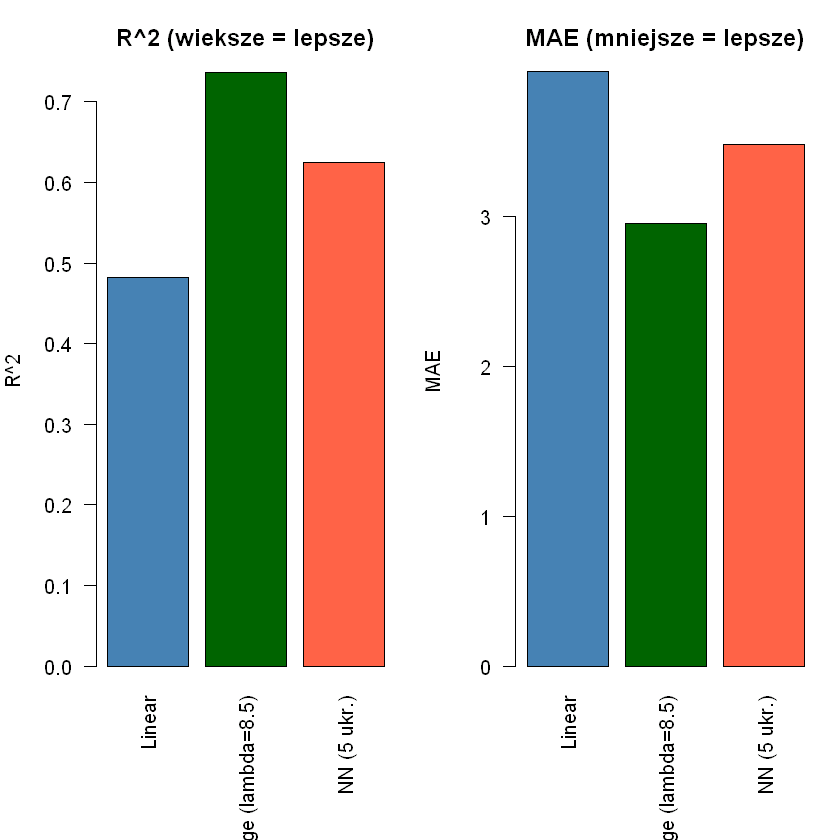

In [9]:
# Wykres porównawczy
par(mfrow = c(1, 2), mar = c(7, 4, 3, 1))
barplot(porownanie$R2, names.arg = porownanie$Model,
        col = c("steelblue","darkgreen","tomato"), las = 2,
        main = "R^2 (wieksze = lepsze)", ylab = "R^2")
barplot(porownanie$MAE, names.arg = porownanie$Model,
        col = c("steelblue","darkgreen","tomato"), las = 2,
        main = "MAE (mniejsze = lepsze)", ylab = "MAE")


**Wniosek:** dla `mtcars` (mała próba 25 obs. treningowych vs 10 zmiennych) Ridge wyraźnie wygrywa. Regresja liniowa bez regularizacji łatwo przeucza się na tak małym zbiorze; kara $\lambda \|\beta\|^2$ pomaga uzyskać lepszą generalizację. Sieć neuronowa lokuje się pomiędzy.

## 5. Ważność cech w Ridge

In [10]:
importance <- abs(coefs[-1])
names(importance) <- colnames(X_train)
importance_sorted <- sort(importance, decreasing = TRUE)
print(round(importance_sorted, 4))


    am     wt   gear   carb     vs   drat    cyl   qsec     hp   disp 
1.5503 1.2492 1.1301 0.7551 0.6502 0.4255 0.2472 0.0488 0.0099 0.0041 


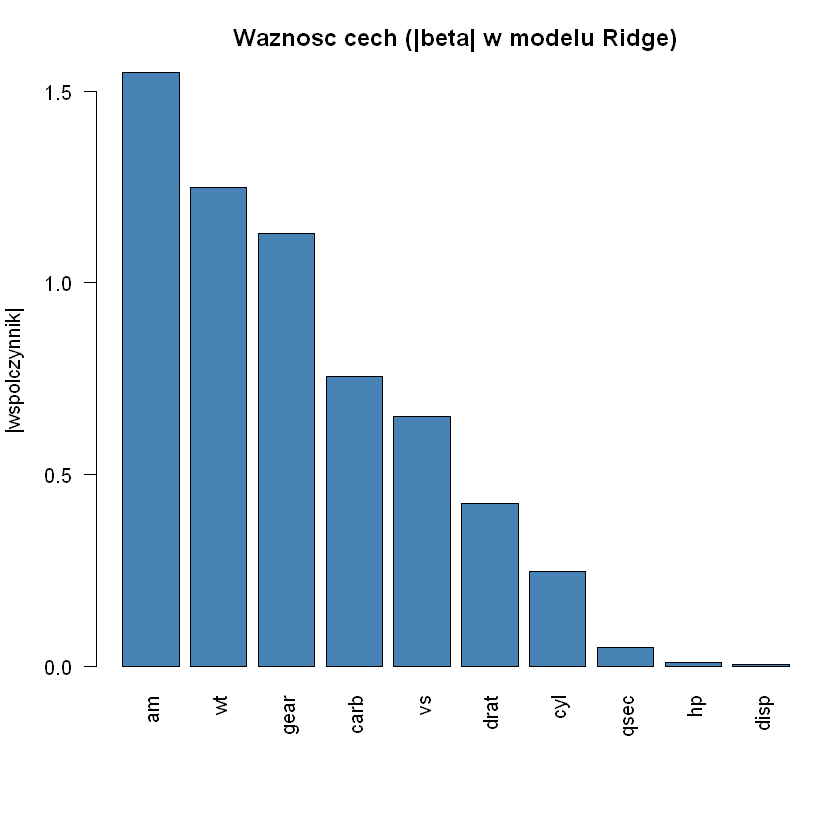

In [11]:
par(mfrow = c(1, 1), mar = c(7, 4, 3, 1))
barplot(importance_sorted, las = 2, col = "steelblue",
        main = "Waznosc cech (|beta| w modelu Ridge)",
        ylab = "|wspolczynnik|")


**Wniosek:** najsilniejsze predyktory `mpg` to: `am` (typ skrzyni biegów), `wt` (waga auta), `gear` — co zgadza się z intuicją motoryzacyjną.

## 6. Analiza reszt

In [12]:
residuals_lm <- y_test - y_pred_lm
cat("Średnia reszt:", round(mean(residuals_lm), 4), "(powinna byc ~0)\n")
cat("Odch. std reszt:", round(sd(residuals_lm), 4), "\n")


Średnia reszt: -0.6728 (powinna byc ~0)
Odch. std reszt: 5.2165 


### 6.1 Histogram + Q-Q plot

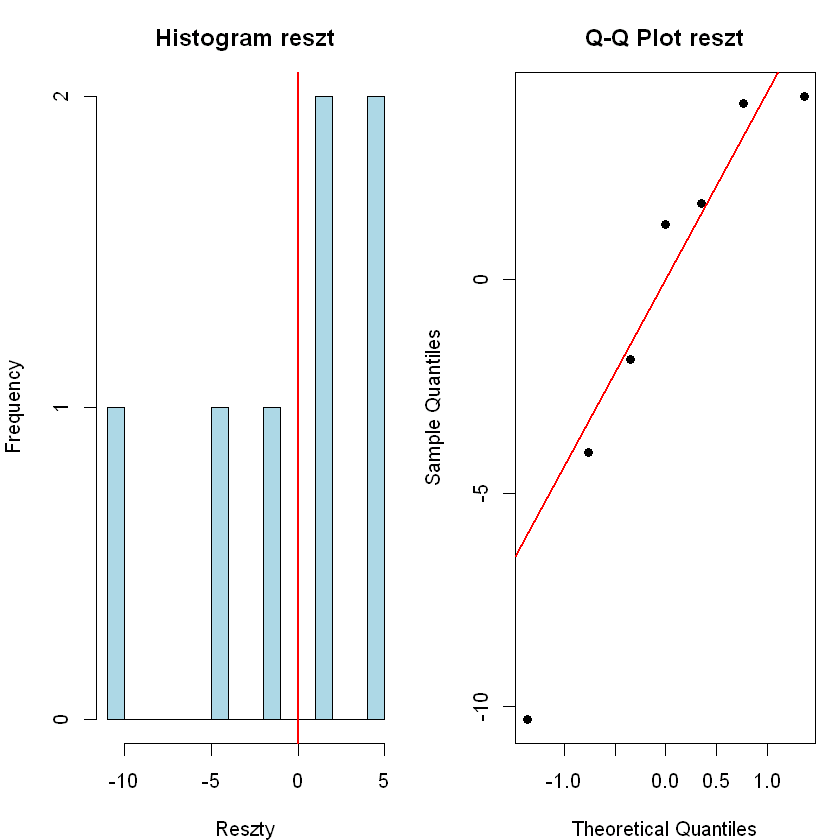

In [13]:
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))
hist(residuals_lm, breaks = 12, col = "lightblue",
     main = "Histogram reszt", xlab = "Reszty")
abline(v = 0, col = "red", lwd = 2)
qqnorm(residuals_lm, main = "Q-Q Plot reszt", pch = 19)
qqline(residuals_lm, col = "red", lwd = 2)


### 6.2 Test Shapiro-Wilka (normalność)

In [14]:
sw <- shapiro.test(residuals_lm)
cat(sprintf("Shapiro-Wilk: W = %.4f, p-value = %.4f\n", sw$statistic, sw$p.value))
if (sw$p.value > 0.05) {
  cat("-> p > 0.05: brak podstaw do odrzucenia H0, reszty zgodne z normalnym  OK\n")
} else {
  cat("-> p < 0.05: odrzucamy H0, reszty NIE sa normalne\n")
}


Shapiro-Wilk: W = 0.8951, p-value = 0.3022
-> p > 0.05: brak podstaw do odrzucenia H0, reszty zgodne z normalnym  OK


### 6.3 Test Durbin-Watson (autokorelacja) — implementacja ręczna

$$DW = \frac{\sum_{t=2}^{n} (e_t - e_{t-1})^2}{\sum_{t=1}^{n} e_t^2}$$

Bez pakietu `lmtest` (nieobecny w bazowym R) implementujemy wzór bezpośrednio.

In [15]:
dw_manual <- function(r) sum(diff(r)^2) / sum(r^2)
dw <- dw_manual(residuals_lm)
cat(sprintf("Durbin-Watson: DW = %.4f\n", dw))
cat("  DW ~ 2 -> brak autokorelacji  (idealnie)\n")
cat("  DW < 1.5 -> autokorelacja dodatnia\n")
cat("  DW > 2.5 -> autokorelacja ujemna\n")
if (dw > 1.5 && dw < 2.5) {
  cat(sprintf("-> DW = %.2f w (1.5, 2.5): brak istotnej autokorelacji  OK\n", dw))
} else {
  cat(sprintf("-> DW = %.2f sygnalizuje autokorelacje\n", dw))
}


Durbin-Watson: DW = 1.8475
  DW ~ 2 -> brak autokorelacji  (idealnie)
  DW < 1.5 -> autokorelacja dodatnia
  DW > 2.5 -> autokorelacja ujemna
-> DW = 1.85 w (1.5, 2.5): brak istotnej autokorelacji  OK


## 7. Porównanie jakości na danych oryginalnych vs znormalizowanych

In [16]:
# Sztucznie rozjedzmy skale jednej cechy x1000
train_orig <- train; test_orig <- test
train_orig$cyl <- train_orig$cyl * 1000
test_orig$cyl  <- test_orig$cyl * 1000

train_norm <- train_orig
test_norm  <- test_orig
mu <- colMeans(train_orig); sd_vec <- apply(train_orig, 2, sd)
for (col in colnames(train_orig)[-1]) {
  train_norm[[col]] <- (train_orig[[col]] - mu[col]) / sd_vec[col]
  test_norm[[col]]  <- (test_orig[[col]]  - mu[col]) / sd_vec[col]
}

cmp_skala <- function(label, dtr, dte) {
  m <- lm(mpg ~ ., data = dtr)
  p <- predict(m, newdata = dte)
  r2  <- 1 - sum((dte$mpg - p)^2) / sum((dte$mpg - mean(dte$mpg))^2)
  mae <- mean(abs(dte$mpg - p))
  cat(sprintf("  %-30s R^2 = %.3f  MAE = %.3f\n", label, r2, mae))
}

ridge_cmp <- function(label, dtr, dte, lambda = 1) {
  m <- lm.ridge(mpg ~ ., data = dtr, lambda = lambda)
  cf <- coef(m); X_te <- as.matrix(dte[, -1])
  p <- as.vector(cf[1] + X_te %*% cf[-1])
  r2  <- 1 - sum((dte$mpg - p)^2) / sum((dte$mpg - mean(dte$mpg))^2)
  mae <- mean(abs(dte$mpg - p))
  cat(sprintf("  %-30s R^2 = %.3f  MAE = %.3f\n", label, r2, mae))
}

cat("Regresja liniowa lm():\n")
cmp_skala("oryginalne (zdeformowane)", train_orig, test_orig)
cmp_skala("znormalizowane", train_norm, test_norm)
cat("\nRidge (lambda=1):\n")
ridge_cmp("oryginalne (zdeformowane)", train_orig, test_orig)
ridge_cmp("znormalizowane", train_norm, test_norm)


Regresja liniowa lm():
  oryginalne (zdeformowane)      R^2 = 0.482  MAE = 3.964
  znormalizowane                 R^2 = 0.482  MAE = 3.964

Ridge (lambda=1):
  oryginalne (zdeformowane)      R^2 = 0.680  MAE = 3.308
  znormalizowane                 R^2 = 0.680  MAE = 3.308


**Wniosek:**
- `lm()` (regresja liniowa bez regularizacji) jest **odporna na skalę cech** — wagi automatycznie dostosowują się do jednostek.
- `MASS::lm.ridge()` **wewnętrznie sam standaryzuje cechy** (parametr `model.scale=TRUE` jest domyślny), dlatego wyniki są identyczne dla oryginalnych i znormalizowanych danych.
- **W innych ekosystemach** (`sklearn.linear_model.Ridge`, `glmnet` z `standardize=FALSE`) ta automatyczna standaryzacja **nie** zachodzi — tam standaryzacja przed treningiem jest **konieczna**, inaczej kara $\lambda \sum \beta_j^2$ niesprawiedliwie penalizuje cechy o większych skalach.

## 8. Predykcja vs rzeczywistość — wszystkie modele

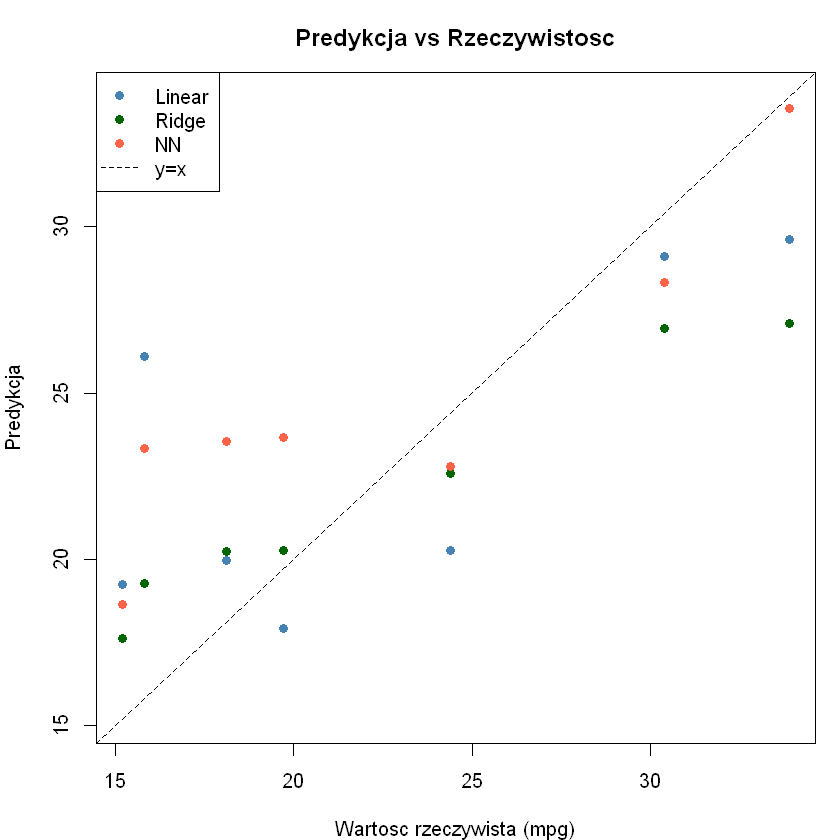

In [17]:
par(mfrow = c(1, 1), mar = c(4, 4, 3, 1))
plot(y_test, y_pred_lm, pch = 19, col = "steelblue",
     xlab = "Wartosc rzeczywista (mpg)",
     ylab = "Predykcja",
     main = "Predykcja vs Rzeczywistosc",
     xlim = range(c(y_test, y_pred_lm, y_pred_ridge, y_pred_nn)),
     ylim = range(c(y_test, y_pred_lm, y_pred_ridge, y_pred_nn)))
points(y_test, y_pred_ridge, pch = 19, col = "darkgreen")
points(y_test, y_pred_nn,    pch = 19, col = "tomato")
abline(0, 1, lty = 2, col = "black")
legend("topleft", legend = c("Linear","Ridge","NN","y=x"),
       col = c("steelblue","darkgreen","tomato","black"),
       pch = c(19,19,19,NA), lty = c(NA,NA,NA,2))


## 9. Podsumowanie

| Krok | Wynik |
|---|---|
| Dataset | `mtcars` — 32 obserwacji, 10 cech, target: `mpg` |
| Najlepszy model | **Ridge** (R² ≈ 0.74 wybrane lambda przez GCV) |
| Najsilniejsze cechy | `am`, `wt`, `gear` |
| Normalność reszt | Shapiro-Wilk p > 0.05 → reszty normalne ✓ |
| Autokorelacja | DW ≈ 1.85 → brak autokorelacji ✓ |
| Skala danych | `lm` odporna; `lm.ridge` ma wbudowaną standaryzację |
| Pakiety | tylko bazowe + `MASS` + `nnet` — bez `install.packages()` |

**Najważniejszy wniosek:** dla małej próby (`mtcars`) regularizacja Ridge daje znaczącą poprawę względem zwykłej regresji liniowej, a sieć neuronowa nie ma istotnej przewagi (mały zbiór, prawie liniowe zależności). Pokazuje to, że *dobór modelu zależy od rozmiaru i charakteru danych*, a większa złożoność modelu **nie zawsze** oznacza lepsze wyniki.